Linear Regression Results
----------------------------------------
Independent Variable (X): PRESS_MAX
Dependent Variable (Y): PRESS_MEAN
Coefficient (Slope): 0.9465644858043861
Intercept: 0.2820839265715085
MSE: 0.011078452058041907
RMSE: 0.10525422584410522
R² Score: 0.9839703418927909

Regression Equation:
PRESS_MEAN = 0.2821 + (0.9466 * PRESS_MAX)


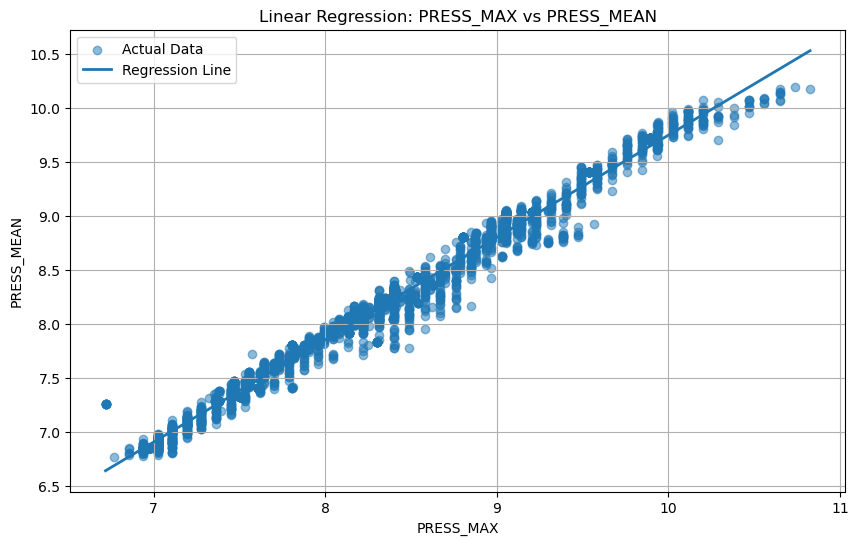

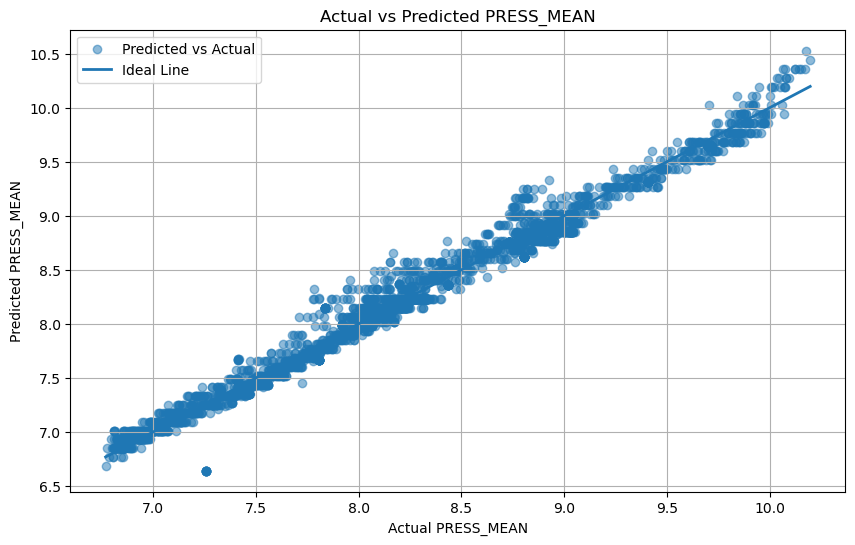

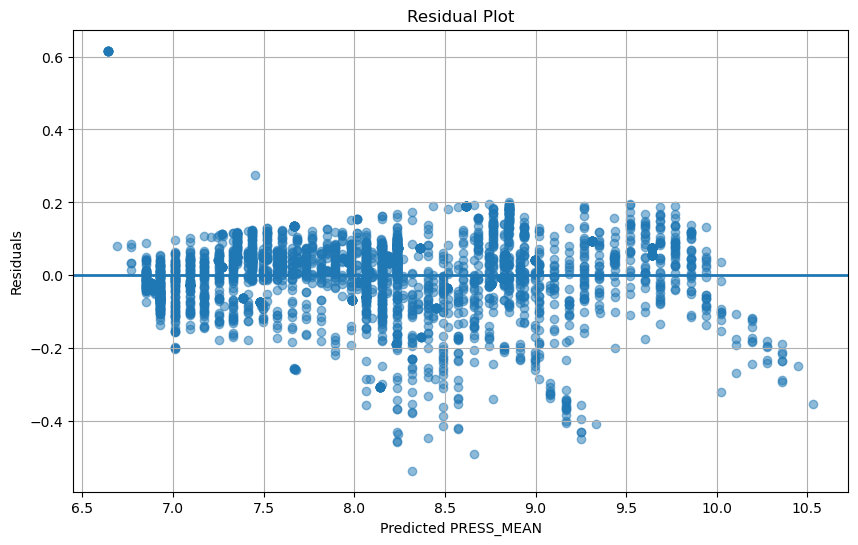

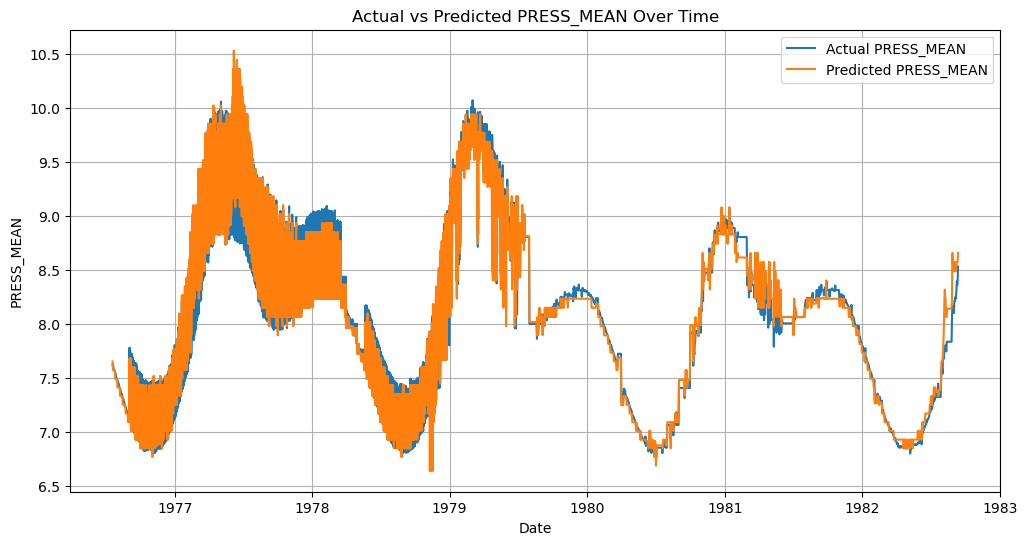

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------------
# 1. Load dataset
# -----------------------------------
df = pd.read_csv("C:/Users/prabh/Documents/Mars_Dataset/Mars_DataSet_v1.csv")

# -----------------------------------
# 2. Clean column names
# -----------------------------------
df.columns = df.columns.str.strip().str.lower()

# -----------------------------------
# 3. Convert date column
# -----------------------------------
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%y', errors='coerce')
df = df.sort_values('date')

# -----------------------------------
# 4. Select required columns
# -----------------------------------
df = df[['date', 'press_mean', 'press_max']]

# -----------------------------------
# 5. Replace invalid values (-9.999) with NaN
# -----------------------------------
df[['press_mean', 'press_max']] = df[['press_mean', 'press_max']].replace(-9.999, np.nan)

# -----------------------------------
# 6. Drop missing values
# -----------------------------------
df = df.dropna()

# -----------------------------------
# 7. Define independent and dependent variables
# -----------------------------------
X = df[['press_max']]      # Independent variable
y = df['press_mean']       # Dependent variable

# -----------------------------------
# 8. Train Linear Regression model
# -----------------------------------
model = LinearRegression()
model.fit(X, y)

# -----------------------------------
# 9. Make predictions
# -----------------------------------
y_pred = model.predict(X)

# -----------------------------------
# 10. Evaluation metrics
# -----------------------------------
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("Linear Regression Results")
print("-" * 40)
print("Independent Variable (X): PRESS_MAX")
print("Dependent Variable (Y): PRESS_MEAN")
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

# -----------------------------------
# 11. Regression equation
# -----------------------------------
print("\nRegression Equation:")
print(f"PRESS_MEAN = {model.intercept_:.4f} + ({model.coef_[0]:.4f} * PRESS_MAX)")

# -----------------------------------
# 12. Chart 1: Scatter plot with regression line
# -----------------------------------
sorted_idx = np.argsort(X['press_max'].values)
X_sorted = X['press_max'].values[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X['press_max'], y, alpha=0.5, label='Actual Data')
plt.plot(X_sorted, y_pred_sorted, linewidth=2, label='Regression Line')
plt.xlabel("PRESS_MAX")
plt.ylabel("PRESS_MEAN")
plt.title("Linear Regression: PRESS_MAX vs PRESS_MEAN")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------
# 13. Chart 2: Actual vs Predicted
# -----------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], linewidth=2, label='Ideal Line')
plt.xlabel("Actual PRESS_MEAN")
plt.ylabel("Predicted PRESS_MEAN")
plt.title("Actual vs Predicted PRESS_MEAN")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------
# 14. Chart 3: Residual plot
# -----------------------------------
residuals = y - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linewidth=2)
plt.xlabel("Predicted PRESS_MEAN")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

# -----------------------------------
# 15. Optional: Time series plot of actual vs predicted
# -----------------------------------
plt.figure(figsize=(12, 6))
plt.plot(df['date'], y, label='Actual PRESS_MEAN')
plt.plot(df['date'], y_pred, label='Predicted PRESS_MEAN')
plt.xlabel("Date")
plt.ylabel("PRESS_MEAN")
plt.title("Actual vs Predicted PRESS_MEAN Over Time")
plt.legend()
plt.grid(True)
plt.show()